Treinando uma Rede Convolucional para o MNIST dataset

In [2]:
# Leitura da base

In [1]:
from tensorflow import keras

# Carrega o conjunto de dados MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Formato dos dados de treino: {x_train.shape}")
print(f"Formato dos rótulos de treino: {y_train.shape}")
print(f"Formato dos dados de teste: {x_test.shape}")
print(f"Formato dos rótulos de teste: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Formato dos dados de treino: (60000, 28, 28)
Formato dos rótulos de treino: (60000,)
Formato dos dados de teste: (10000, 28, 28)
Formato dos rótulos de teste: (10000,)


In [4]:
x_train.shape

(60000, 28, 28)

In [7]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

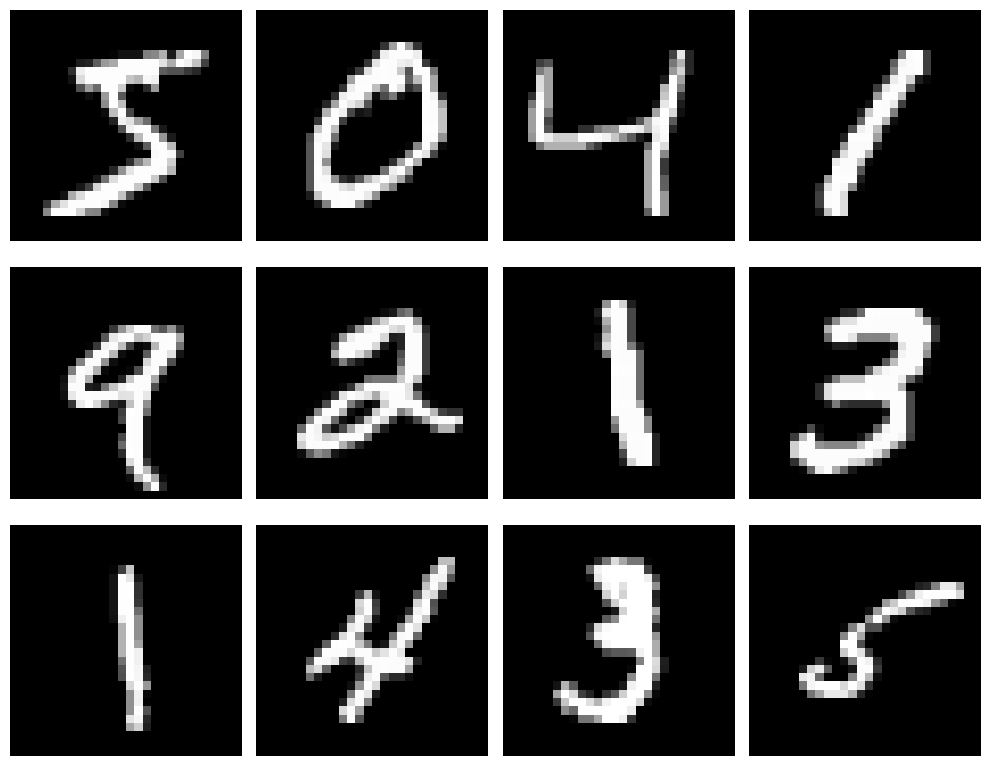

In [8]:
import matplotlib.pyplot as plt

# Define o tamanho do grid
num_rows = 3
num_cols = 4
num_images = num_rows * num_cols

# Cria a figura e os subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 8))

# Achata o array de eixos para facilitar a iteração
axes = axes.flatten()

# Itera sobre as primeiras 'num_images' imagens do x_train
for i in range(num_images):
    axes[i].imshow(x_train[i], cmap='gray')
    axes[i].axis('off') # Remove os eixos para uma visualização mais limpa

plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()


In [10]:
y_train[:12]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5], dtype=uint8)

In [11]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

In [15]:
import numpy as np

In [17]:
np.min(x_train[0])

np.uint8(0)

In [16]:
np.max(x_train[0])

np.uint8(255)

In [ ]:
# trinando uma CNN no MNIST

In [18]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

# --- Pre-processamento dos dados ---

# Normalizar os dados de imagem para o intervalo [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Redimensionar as imagens para incluir o canal (28x28x1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Converter os rótulos para o formato one-hot encoding
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print(f"Formato dos dados de treino após pré-processamento: {x_train.shape}")
print(f"Formato dos rótulos de treino após pré-processamento: {y_train.shape}")
print(f"Formato dos dados de teste após pré-processamento: {x_test.shape}")
print(f"Formato dos rótulos de teste após pré-processamento: {y_test.shape}")

Formato dos dados de treino após pré-processamento: (60000, 28, 28, 1)
Formato dos rótulos de treino após pré-processamento: (60000, 10)
Formato dos dados de teste após pré-processamento: (10000, 28, 28, 1)
Formato dos rótulos de teste após pré-processamento: (10000, 10)


In [21]:
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [23]:
np.max(x_train[0])

np.float32(1.0)

In [29]:


# --- Definição da arquitetura LeNet-5 ---

model = Sequential([
    # Camada C1: Convolucional com 6 filtros 5x5, ativação ReLU
    # LeNet-5 original usa entrada 32x32, vamos adaptar para 28x28
    Conv2D(filters=6, kernel_size=(5, 5), activation='relu', input_shape=(28, 28, 1)),
    # Camada S2: Pooling médio com filtro 2x2, stride 2
    AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Camada C3: Convolucional com 16 filtros 5x5, ativação ReLU
    Conv2D(filters=16, kernel_size=(5, 5), activation='relu'),
    # Camada S4: Pooling médio com filtro 2x2, stride 2
    AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Achatamento (Flatten) para conectar com as camadas densas
    Flatten(),

    # Camada C5 (ou F5): Densa com 120 unidades, ativação ReLU
    Dense(units=120, activation='relu'),
    # Camada F6: Densa com 84 unidades, ativação ReLU
    Dense(units=84, activation='relu'),

    # Camada de Saída: Densa com 10 unidades (para 10 classes), ativação Softmax
    Dense(units=10, activation='softmax')
])

# --- Compilação do Modelo ---

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- Resumo do Modelo ---

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
x_train.shape

(60000, 28, 28, 1)

In [30]:
# --- Treinamento do Modelo ---
history = model.fit(
    x_train[:1000],
    y_train[:1000],
    epochs=10,
    validation_data=(x_test, y_test),
    verbose=1
)



Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 0.2347 - loss: 2.2470 - val_accuracy: 0.6219 - val_loss: 1.6184
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.6713 - loss: 1.2838 - val_accuracy: 0.7634 - val_loss: 0.7260
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.8291 - loss: 0.6011 - val_accuracy: 0.8458 - val_loss: 0.5106
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step - accuracy: 0.8495 - loss: 0.4812 - val_accuracy: 0.8503 - val_loss: 0.4834
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.9096 - loss: 0.3337 - val_accuracy: 0.8721 - val_loss: 0.4304
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.9164 - loss: 0.2892 - val_accuracy: 0.8809 - val_loss: 0.3856
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.9258 - loss: 0.2497 - val_accuracy: 0.8884 - val_loss: 0.3559
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step - accuracy: 0.9344 - loss: 0.2050 - val_accuracy: 0.9094 -

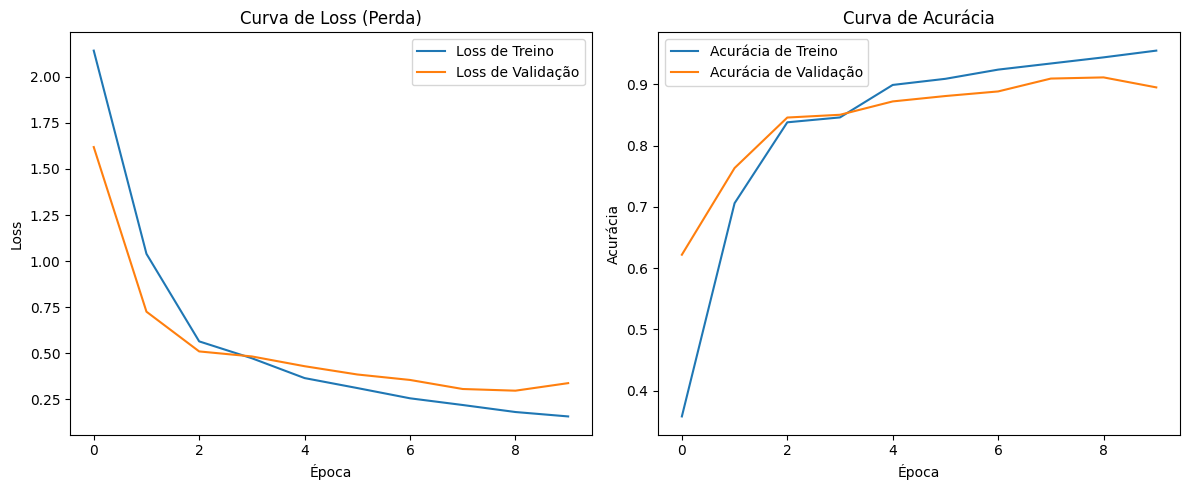

In [31]:
# --- Plotagem da Loss e Accuracy ---
import matplotlib.pyplot as plt

# Plotar a Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss de Treino')
plt.plot(history.history['val_loss'], label='Loss de Validação')
plt.title('Curva de Loss (Perda)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

# Plotar a Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Acurácia de Treino')
plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
plt.title('Curva de Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

plt.tight_layout()
plt.show()

## Agora Testando com o Fashion MNIST

# Task
Analyze the Fashion MNIST dataset by loading it, visualizing sample images, pre-processing the data (normalizing and one-hot encoding), defining and compiling a LeNet-5 convolutional neural network, training the model for 10 epochs, and finally plotting the training and validation loss and accuracy curves.

## Load Fashion MNIST Dataset

### Subtask:
Load the Fashion MNIST dataset using `keras.datasets.fashion_mnist.load_data()`.


**Reasoning**:
To load the Fashion MNIST dataset, I need to import it from `keras.datasets` and then call the `load_data()` function, assigning the output to the specified variables.



In [32]:
from tensorflow import keras

# Load the Fashion MNIST dataset
(x_train_fashion, y_train_fashion), (x_test_fashion, y_test_fashion) = keras.datasets.fashion_mnist.load_data()

print(f"Formato dos dados de treino Fashion MNIST: {x_train_fashion.shape}")
print(f"Formato dos rótulos de treino Fashion MNIST: {y_train_fashion.shape}")
print(f"Formato dos dados de teste Fashion MNIST: {x_test_fashion.shape}")
print(f"Formato dos rótulos de teste Fashion MNIST: {y_test_fashion.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Formato dos dados de treino Fashion MNIST: (60000, 28, 28)
Formato dos rótulos de treino Fashion MNIST: (60000,)
Formato dos dados de teste Fashion MNIST: (10000, 28, 28)
Formato dos rótulos de teste Fashion MNIST: (10000,)


## Plot Fashion MNIST Examples

### Subtask:
Plot a grid of 3x4 images from the Fashion MNIST training set (`x_train_fashion`) to visualize the data, similar to the previous MNIST visualization.


**Reasoning**:
I need to visualize a grid of Fashion MNIST images. The instructions specify to plot 3x4 images from the `x_train_fashion` dataset, similar to the previous visualization. I will use `matplotlib.pyplot` to create the subplots and display the images, ensuring proper layout and axis removal for clarity.



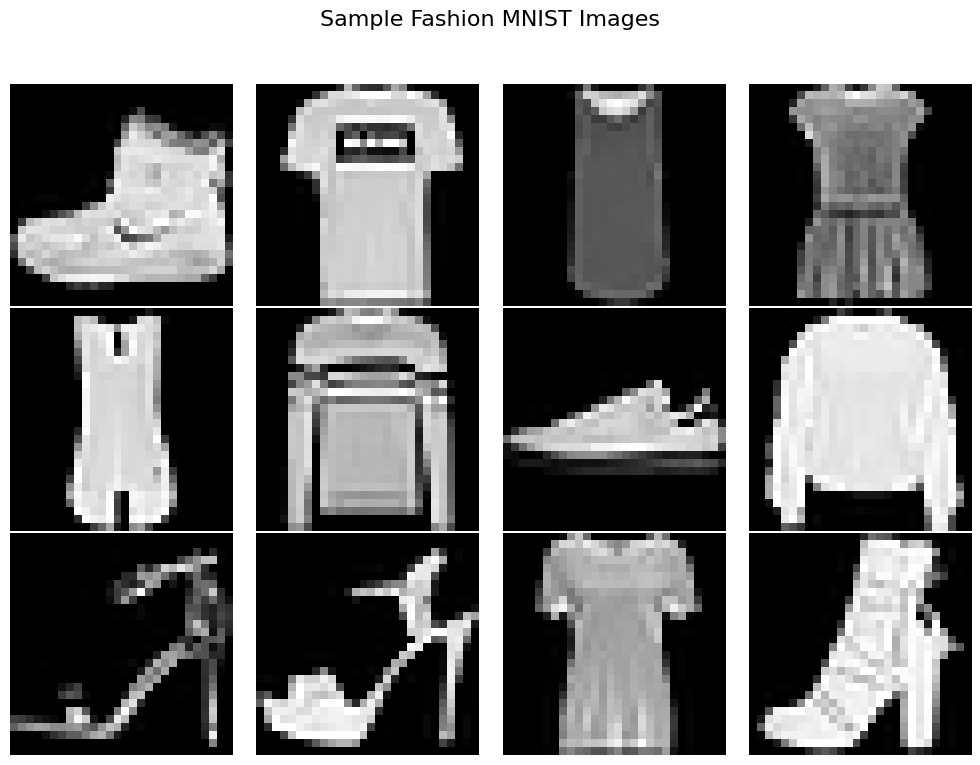

In [33]:
import matplotlib.pyplot as plt

# Define o tamanho do grid
num_rows = 3
num_cols = 4
num_images = num_rows * num_cols

# Cria a figura e os subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 8))

# Achata o array de eixos para facilitar a iteração
axes = axes.flatten()

# Itera sobre as primeiras 'num_images' imagens do x_train_fashion
for i in range(num_images):
    axes[i].imshow(x_train_fashion[i], cmap='gray')
    axes[i].axis('off') # Remove os eixos para uma visualização mais limpa

plt.suptitle('Sample Fashion MNIST Images', fontsize=16) # Add a main title
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta o layout para evitar sobreposição, deixando espaço para o título
plt.show()

## Pre-process Fashion MNIST Data

### Subtask:
Pre-process the Fashion MNIST data by normalizing the image pixel values to the range [0, 1] and converting the labels (`y_train_fashion`, `y_test_fashion`) to one-hot encoding.

## Pre-process Fashion MNIST Data

### Subtask:
Pre-process the Fashion MNIST data by normalizing the image pixel values to the range [0, 1] and converting the labels (`y_train_fashion`, `y_test_fashion`) to one-hot encoding.

**Reasoning**:
Now that the subtask for pre-processing Fashion MNIST data has been introduced, I will generate the code to perform the normalization and one-hot encoding as specified in the subtask instructions. This involves converting image pixel values to float32 and scaling them to [0, 1], expanding the dimensions to include a channel, and then applying one-hot encoding to the labels.



In [34]:
import numpy as np
from tensorflow.keras.utils import to_categorical

# --- Pre-processamento dos dados Fashion MNIST ---

# Normalizar os dados de imagem para o intervalo [0, 1]
x_train_fashion = x_train_fashion.astype('float32') / 255.0
x_test_fashion = x_test_fashion.astype('float32') / 255.0

# Redimensionar as imagens para incluir o canal (28x28x1)
x_train_fashion = np.expand_dims(x_train_fashion, -1)
x_test_fashion = np.expand_dims(x_test_fashion, -1)

# Converter os rótulos para o formato one-hot encoding
y_train_fashion = to_categorical(y_train_fashion, num_classes=10)
y_test_fashion = to_categorical(y_test_fashion, num_classes=10)

print(f"Formato dos dados de treino Fashion MNIST após pré-processamento: {x_train_fashion.shape}")
print(f"Formato dos rótulos de treino Fashion MNIST após pré-processamento: {y_train_fashion.shape}")
print(f"Formato dos dados de teste Fashion MNIST após pré-processamento: {x_test_fashion.shape}")
print(f"Formato dos rótulos de teste Fashion MNIST após pré-processamento: {y_test_fashion.shape}")

Formato dos dados de treino Fashion MNIST após pré-processamento: (60000, 28, 28, 1)
Formato dos rótulos de treino Fashion MNIST após pré-processamento: (60000, 10)
Formato dos dados de teste Fashion MNIST após pré-processamento: (10000, 28, 28, 1)
Formato dos rótulos de teste Fashion MNIST após pré-processamento: (10000, 10)


## Define and Compile LeNet-5 for Fashion MNIST

### Subtask:
Define and compile a LeNet-5 convolutional neural network using `tensorflow.keras.models.Sequential`, similar to the MNIST model, but adapted for the Fashion MNIST dataset. Use 'adam' optimizer, 'categorical_crossentropy' loss, and 'accuracy' metrics.

**Reasoning**:
The subtask now requires defining and compiling the LeNet-5 model for the Fashion MNIST dataset. I will generate a code block that creates the Sequential model with the specified layers, optimizer, loss function, and metrics.



In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

# --- Definição da arquitetura LeNet-5 para Fashion MNIST ---

model_fashion = Sequential([
    # Camada C1: Convolucional com 6 filtros 5x5, ativação ReLU
    Conv2D(filters=6, kernel_size=(5, 5), activation='relu', input_shape=(28, 28, 1)),
    # Camada S2: Pooling médio com filtro 2x2, stride 2
    AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Camada C3: Convolucional com 16 filtros 5x5, ativação ReLU
    Conv2D(filters=16, kernel_size=(5, 5), activation='relu'),
    # Camada S4: Pooling médio com filtro 2x2, stride 2
    AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Achatamento (Flatten) para conectar com as camadas densas
    Flatten(),

    # Camada C5 (ou F5): Densa com 120 unidades, ativação ReLU
    Dense(units=120, activation='relu'),
    # Camada F6: Densa com 84 unidades, ativação ReLU
    Dense(units=84, activation='relu'),

    # Camada de Saída: Densa com 10 unidades (para 10 classes), ativação Softmax
    Dense(units=10, activation='softmax')
])

# --- Compilação do Modelo Fashion MNIST ---

model_fashion.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- Resumo do Modelo Fashion MNIST ---

model_fashion.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_6             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_7             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# --- Treinamento do Modelo ---
history = model_fashion.fit(
    x_train_fashion[:1000],
    y_train_fashion[:1000],
    epochs=10,
    validation_data=(x_test_fashion, y_test_fashion),
    verbose=1
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.2451 - loss: 2.2608 - val_accuracy: 0.4899 - val_loss: 1.8134
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.5257 - loss: 1.5033 - val_accuracy: 0.6390 - val_loss: 1.0347
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.6416 - loss: 0.9672 - val_accuracy: 0.6678 - val_loss: 0.8664
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.7230 - loss: 0.7509 - val_accuracy: 0.6884 - val_loss: 0.7897
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.7036 - loss: 0.7508 - val_accuracy: 0.6888 - val_loss: 0.7713
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.7364 - loss: 0.6755 - val_accuracy: 0.7184 - val_loss: 0.7000
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.7592 - loss: 0.6407 - val_accuracy: 0.7046 - val_loss: 0.7438
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.7734 - loss: 0.6070 - val_accuracy: 0.7315 

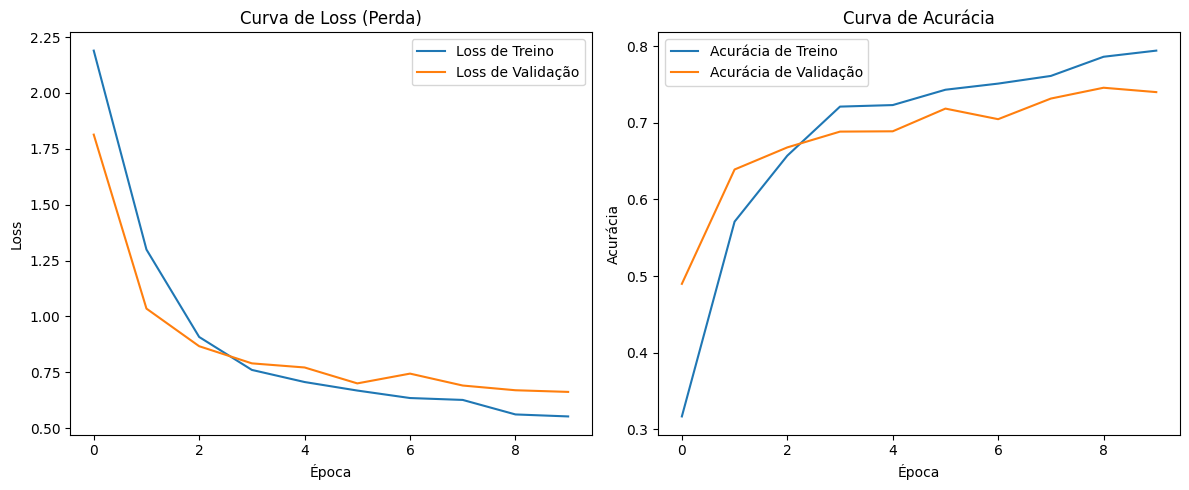

In [47]:
# --- Plotagem da Loss e Accuracy ---
import matplotlib.pyplot as plt

# Plotar a Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss de Treino')
plt.plot(history.history['val_loss'], label='Loss de Validação')
plt.title('Curva de Loss (Perda)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

# Plotar a Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Acurácia de Treino')
plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
plt.title('Curva de Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

plt.tight_layout()
plt.show()